In [1]:
import numpy as np
import os
import glob
import yaml
import matplotlib.pyplot as plt
import fivebeads
import json

parent_dir = "/Volumes/Bit Bank 1/Research/Neural_Estimation/N_dis2"
coarse_steps= ["01", "02", "03", "04", "05", "06", "10", "12", "15"]
num_trials = 12

folders = sorted([f for f in os.listdir(parent_dir) if os.path.isdir(os.path.join(parent_dir, f))])


N = []
for folder in folders:
    yaml_file_path = os.path.join(parent_dir, folder, "config.yaml")
    with open(yaml_file_path, "r") as file:
        config = yaml.safe_load(file)
    num_paths = config.get('training', {}).get('epoch_s')
    N.append(num_paths)
N, folders

([8000, 16000, 40000, 80000, 160000, 400000, 800000],
 ['02_10_19_5351',
  '02_10_20_1153',
  '02_10_20_3340',
  '02_10_23_0045',
  '02_11_02_3812',
  '02_11_09_3440',
  '02_12_04_0231'])

In [2]:
trial_folder = os.path.join(parent_dir, folders[-1])
rank_folder = sorted([f for f in os.listdir(trial_folder) if os.path.isdir(os.path.join(trial_folder, f))])
path_folder = os.path.join(trial_folder, rank_folder[-1])
theo_path_dir = os.path.join(path_folder, "theo_path_diss_cum.npy")
nn_1_1st_path_dir = os.path.join(path_folder, "nn_path_diss_cum_coarse_01_1st.npy")
nn_5_1st_path_dir = os.path.join(path_folder, "nn_path_diss_cum_coarse_05_1st.npy")
nn_10_1st_path_dir = os.path.join(path_folder, "nn_path_diss_cum_coarse_10_1st.npy")
nn_15_1st_path_dir = os.path.join(path_folder, "nn_path_diss_cum_coarse_15_1st.npy")
nn_12_1st_path_dir = os.path.join(path_folder, "nn_path_diss_cum_coarse_12_1st.npy")
theo_path_ep = np.load(theo_path_dir)
nn_path_ep_1_1st = np.load(nn_1_1st_path_dir)
nn_path_ep_5_1st = np.load(nn_5_1st_path_dir)
nn_path_ep_10_1st = np.load(nn_10_1st_path_dir)
nn_path_ep_12_1st = np.load(nn_12_1st_path_dir)
nn_path_ep_15_1st = np.load(nn_15_1st_path_dir)
nn_10_2nd_path_dir = os.path.join(path_folder, "nn_path_diss_cum_coarse_10_2nd.npy")
nn_12_2nd_path_dir = os.path.join(path_folder, "nn_path_diss_cum_coarse_12_2nd.npy")
nn_15_2nd_path_dir = os.path.join(path_folder, "nn_path_diss_cum_coarse_15_2nd.npy")
nn_path_ep_10_2nd = np.load(nn_10_2nd_path_dir)
nn_path_ep_12_2nd = np.load(nn_12_2nd_path_dir)
nn_path_ep_15_2nd = np.load(nn_15_2nd_path_dir)


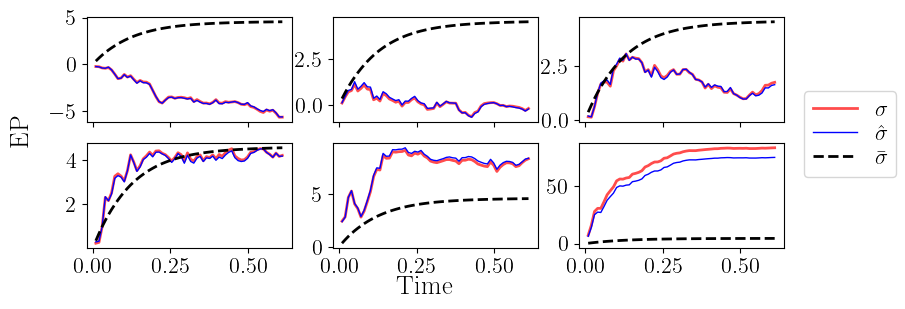

In [50]:
with open("plot_config.json", "r") as f:
    config = json.load(f)
plt.rcParams.update(config)
theo_path_ep_mean = theo_path_ep.mean(axis=0)
idx = np.argsort(theo_path_ep[:,-1])
nn_path_ep_mean = nn_path_ep_1_1st.sum(axis=-1).mean(axis=0)
time  = np.linspace(0.01, 0.61, 60)
fig, ax = plt.subplots(2, 3, figsize=(9, 3))


ax[0,0].plot(time, theo_path_ep[idx[0],:], "r-", alpha=0.7,label=f"$\\sigma_{1}$")
ax[0,1].plot(time, theo_path_ep[idx[40000],:], "r-",alpha=0.7, label=f"$\\sigma_{2}$")
ax[0,2].plot(time, theo_path_ep[idx[80000],:], "r-", alpha=0.7,label=f"$\\sigma_{3}$")
ax[1,0].plot(time, theo_path_ep[idx[120000],:],  "r-",alpha=0.7,label=f"$\\sigma_{3}$")
ax[1,1].plot(time, theo_path_ep[idx[160000],:], "r-", alpha=0.7,label=f"$\\sigma_{4}$")
ax[1,2].plot(time, theo_path_ep[idx[-1],:], "r-", alpha=0.7,label=f"$\\sigma$")

ax[0,0].plot(time, nn_path_ep_1_1st.sum(axis=-1)[idx[0],:], "b-", alpha=1,linewidth=1,label=f"$\\sigma_{1}$")
ax[0,1].plot(time, nn_path_ep_1_1st.sum(axis=-1)[idx[40000],:], "b-",alpha=1,linewidth=1,label=f"NN Path {2}")
ax[0,2].plot(time, nn_path_ep_1_1st.sum(axis=-1)[idx[80000],:], "b-",alpha=1,linewidth=1,label=f"NN Path {3}")
ax[1,0].plot(time, nn_path_ep_1_1st.sum(axis=-1)[idx[120000],:], "b-",alpha=1,linewidth=1,label=f"NN Path {3}")
ax[1,1].plot(time, nn_path_ep_1_1st.sum(axis=-1)[idx[160000],:], "b-",alpha=1,linewidth=1,label=f"NN Path {4}")
ax[1,2].plot(time, nn_path_ep_1_1st.sum(axis=-1)[idx[-1],:], "b-",alpha=1,linewidth=1,label=r" $\hat{\sigma}$")

ax[0,0].plot(time, theo_path_ep_mean, "k--")
ax[0,1].plot(time, theo_path_ep_mean, "k--" )
ax[0,2].plot(time, theo_path_ep_mean, "k--" )
ax[1,0].plot(time, theo_path_ep_mean, "k--")
ax[1,1].plot(time, theo_path_ep_mean, "k--")
ax[1,2].plot(time, theo_path_ep_mean, "k--", label=r" $\bar{\sigma}$")


ax[0,0].set_xticklabels([])
ax[0,1].set_xticklabels([])
ax[0,2].set_xticklabels([])
fig.supxlabel("Time", y=-0.06)
fig.supylabel("EP",x=0.04)
plt.legend(bbox_to_anchor=(1.6, 1.6))
plt.savefig("figs/nn_stochastic_ep_no_coarse.pdf", bbox_inches='tight')
plt.show()





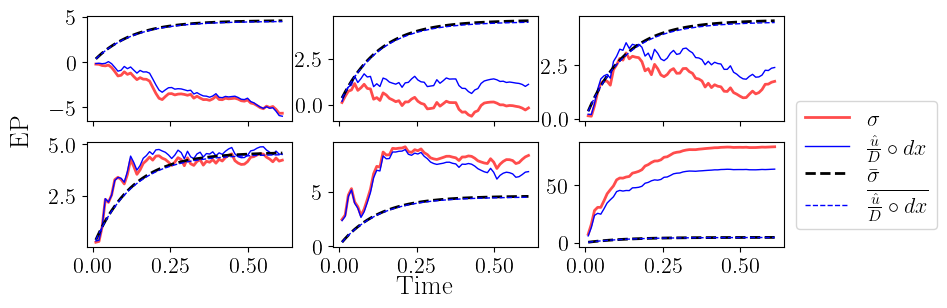

In [ ]:
with open("plot_config.json", "r") as f:
    config = json.load(f)
plt.rcParams.update(config)
theo_path_ep_mean = theo_path_ep.mean(axis=0)
idx = np.argsort(theo_path_ep[:,-1])
nn_path_ep_mean = nn_path_ep_1_1st.sum(axis=-1).mean(axis=0)
nn_path_u_mean = nn_path_ep_1_1st[:,:,0].mean(axis=0)
time  = np.linspace(0.01, 0.61, 60)
fig, ax = plt.subplots(2, 3, figsize=(9, 3))


ax[0,0].plot(time, theo_path_ep[idx[0],:], "r-", alpha=0.7,label=f"$\\sigma_{1}$")
ax[0,1].plot(time, theo_path_ep[idx[40000],:], "r-",alpha=0.7, label=f"$\\sigma_{2}$")
ax[0,2].plot(time, theo_path_ep[idx[80000],:], "r-", alpha=0.7,label=f"$\\sigma_{3}$")
ax[1,0].plot(time, theo_path_ep[idx[120000],:],  "r-",alpha=0.7,label=f"$\\sigma_{3}$")
ax[1,1].plot(time, theo_path_ep[idx[160000],:], "r-", alpha=0.7,label=f"$\\sigma_{4}$")
ax[1,2].plot(time, theo_path_ep[idx[-1],:], "r-", alpha=0.7,label=f"$\\sigma$")

ax[0,0].plot(time, nn_path_ep_1_1st[idx[0],:,0], "b-", alpha=1,linewidth=1,label=f"$\\sigma_{1}$")
ax[0,1].plot(time, nn_path_ep_1_1st[idx[40000],:,0], "b-",alpha=1,linewidth=1,label=f"NN Path {2}")
ax[0,2].plot(time, nn_path_ep_1_1st[idx[80000],:,0], "b-",alpha=1,linewidth=1,label=f"NN Path {3}")
ax[1,0].plot(time, nn_path_ep_1_1st[idx[120000],:,0], "b-",alpha=1,linewidth=1,label=f"NN Path {3}")
ax[1,1].plot(time, nn_path_ep_1_1st[idx[160000],:,0], "b-",alpha=1,linewidth=1,label=f"NN Path {4}")
ax[1,2].plot(time, nn_path_ep_1_1st[idx[-1],:,0], "b-",alpha=1,linewidth=1,label=r" $\frac{\hat{u}}{D}\circ dx$")

ax[0,0].plot(time, theo_path_ep_mean, "k--")
ax[0,1].plot(time, theo_path_ep_mean, "k--" )
ax[0,2].plot(time, theo_path_ep_mean, "k--" )
ax[1,0].plot(time, theo_path_ep_mean, "k--")
ax[1,1].plot(time, theo_path_ep_mean, "k--")
ax[1,2].plot(time, theo_path_ep_mean, "k--", label=r" $\bar{\sigma}$")

ax[0,0].plot(time, nn_path_u_mean, "b--",linewidth=1)
ax[0,1].plot(time, nn_path_u_mean, "b--",linewidth=1 )
ax[0,2].plot(time, nn_path_u_mean, "b--",linewidth=1) 
ax[1,0].plot(time, nn_path_u_mean, "b--",linewidth=1)
ax[1,1].plot(time, nn_path_u_mean, "b--",linewidth=1)
ax[1,2].plot(time, nn_path_u_mean, "b--",linewidth=1, label=r"$\overline{\frac{\hat{u}}{D}\circ dx}$")


ax[0,0].set_xticklabels([])
ax[0,1].set_xticklabels([])
ax[0,2].set_xticklabels([])
fig.supxlabel("Time", y=-0.06)
fig.supylabel("EP",x=0.04)
plt.legend(bbox_to_anchor=(1.8, 1.5))
#plt.savefig("figs/nn_u_stochastic_ep_compare_no_coarse.pdf", bbox_inches='tight')
plt.show()



[ 17673 141614 159744  33883]


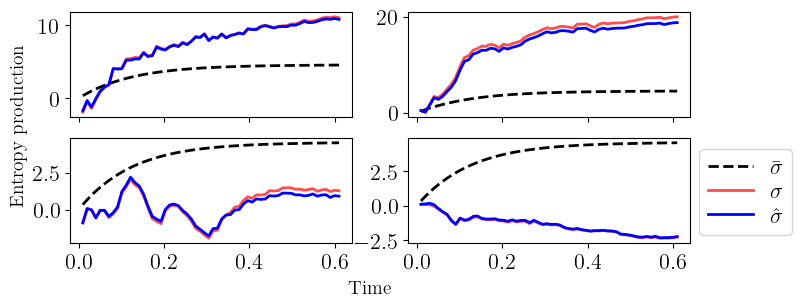

In [ ]:
fig, ax = plt.subplots(2, 2)
index = np.random.randint(0, 200_000, 4)
print(index)
for i in range(2):
    for j in range(2):
        ax[i,j].plot(time, theo_path_ep_mean, "k--", label=r" $\bar{\sigma}$")
        ax[i,j].plot(time, theo_path_ep[index[2*i+j],:], "r-", alpha=0.7,label=f"$\\sigma$")
        ax[i,j].plot(time, nn_path_ep_1_1st.sum(axis=-1)[index[2*i+j],:], "b-", alpha=1,label=r"$\hat{\sigma}$")
for i in range(2):
    ax[0,i].set_xticklabels([])
plt.legend(bbox_to_anchor=(1.4, 1))
fig.supxlabel('Time', y=-.07, fontsize=14   )
fig.supylabel('Entropy production', fontsize=14, x=0.05)

plt.show()


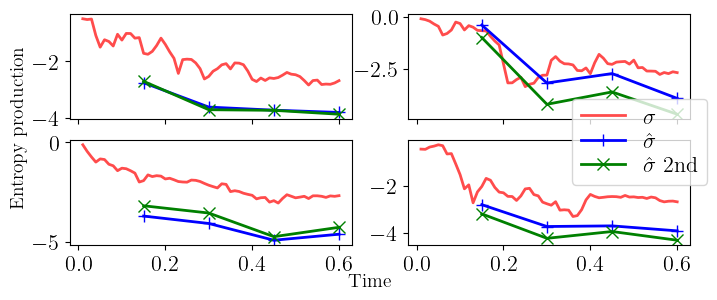

In [12]:
time  = np.linspace(0.01, 0.6, 60)
time_15  = np.linspace(0.15, 0.6, 4)
theo_path_ep_mean = theo_path_ep.mean(axis=0)
index = np.argsort(theo_path_ep[:,-1])[1000:]
fig, ax = plt.subplots(2, 2)

for i in range(2):
    for j in range(2):
        ax[i,j].plot(time, theo_path_ep[index[2*i+j],:], "r-", alpha=0.7,label=f"$\\sigma$")
        ax[i,j].plot(time_15, nn_path_ep_15_1st.sum(axis=-1)[index[2*i+j],:], "b-", marker="+", alpha=1,label=r"$\hat{\sigma}$")
        ax[i,j].plot(time_15, nn_path_ep_15_2nd.sum(axis=-1)[index[2*i+j],:], "g-", marker="x",alpha=1,label=r"$\hat{\sigma}$ 2nd")
for i in range(2):
    ax[0,i].set_xticklabels([])
plt.legend(bbox_to_anchor=(1.1, 1.5))
fig.supxlabel('Time', y=-0.04, fontsize=14   )
fig.supylabel('Entropy production', fontsize=14, x=0.05)

plt.show()


In [10]:
idx

array([103518, 128012, 147838, ..., 182333,  60551, 120979])